In [ ]:
%run CleanData.ipynb

import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import CategoricalCrossentropy
import joblib
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, GRU, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [ ]:
#reshape the train and test sets to 3D — which is required by GRUs ([samples, timesteps, features]).
# X_train, X_test, y_train, y_test = joblib.load("ecg_split_data.pkl")
X_train = X_train.values.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.values.reshape((X_test.shape[0], X_test.shape[1], 1))
y_train = to_categorical(y_train, num_classes=6)
y_test = to_categorical(y_test, num_classes=6)
import numpy as np
np.bincount(np.argmax(y_train, axis=1))

array([75683,  2223,  5788,   641,  6431,  8429])

In [ ]:
# Convert from one-hot to int labels
y_train_int = np.argmax(y_train, axis=1)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_int),
    y=y_train_int
)
class_weights = dict(enumerate(class_weights))
print("Class weights:", class_weights)

Class weights: {0: np.float64(0.21844403630934292), 1: np.float64(7.4370220422852), 2: np.float64(2.8563407049067036), 3: np.float64(25.79173166926677), 4: np.float64(2.570751049603483), 5: np.float64(1.9613833194922292)}


In [ ]:
model = Sequential([
    GRU(64, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(6, activation='softmax')
    
])
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=CategoricalCrossentropy(),
    metrics=['accuracy']
)
# Optional: Add early stopping to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
# Train the model
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    class_weight=class_weights,
    verbose=1
)


Epoch 1/10


c:\Users\hawra\anaconda3\envs\tf-env\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3100/3100 ━━━━━━━━━━━━━━━━━━━━ 122s 39ms/step - accuracy: 0.1227 - loss: 1.5880 - val_accuracy: 0.2560 - val_loss: 1.5119
Epoch 2/10
3100/3100 ━━━━━━━━━━━━━━━━━━━━ 110s 35ms/step - accuracy: 0.2988 - loss: 1.1823 - val_accuracy: 0.3781 - val_loss: 1.1488
Epoch 3/10
3100/3100 ━━━━━━━━━━━━━━━━━━━━ 145s 47ms/step - accuracy: 0.3937 - loss: 0.9249 - val_accuracy: 0.4271 - val_loss: 1.1767
Epoch 4/10
3100/3100 ━━━━━━━━━━━━━━━━━━━━ 201s 65ms/step - accuracy: 0.4713 - loss: 0.7865 - val_accuracy: 0.5006 - val_loss: 1.0276
Epoch 5/10
3100/3100 ━━━━━━━━━━━━━━━━━━━━ 347s 112ms/step - accuracy: 0.5775 - loss: 0.6611 - val_accuracy: 0.5504 - val_loss: 1.0728
Epoch 6/10
3100/3100 ━━━━━━━━━━━━━━━━━━━━ 206s 66ms/step - accuracy: 0.6372 - loss: 0.5900 - val_accuracy: 0.6176 - val_loss: 0.8968
Epoch 7/10
3100/3100 ━━━━━━━━━━━━━━━━━━━━ 205s 66ms/step - accuracy: 0.6848 - loss: 0.5340 - val_accuracy: 0.6393 - val_loss: 0.9549
Epoch 8/10
3100/3100 ━━━━━━━━━━━━━━━━━━━━ 259s 83ms/step - accuracy: 0.7224 - l

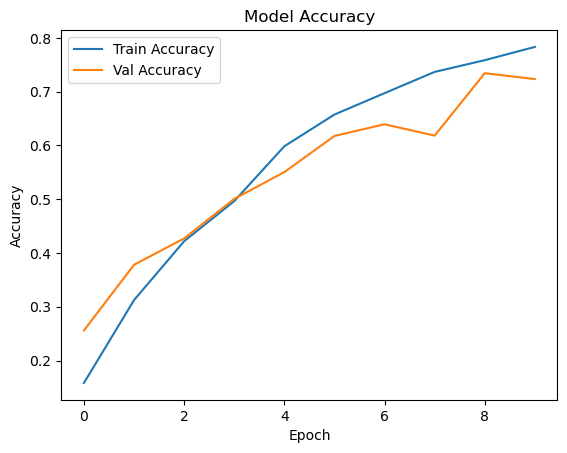

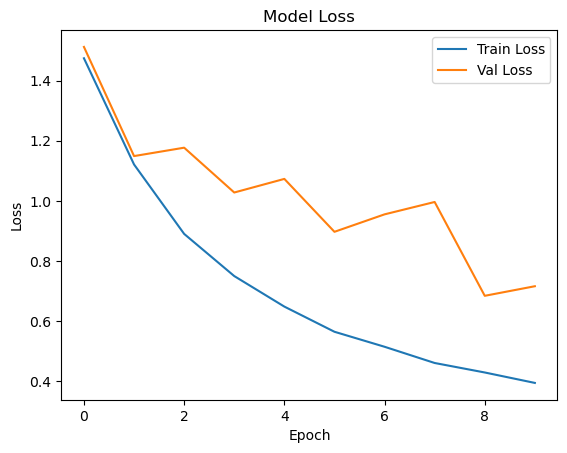

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()


776/776 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step


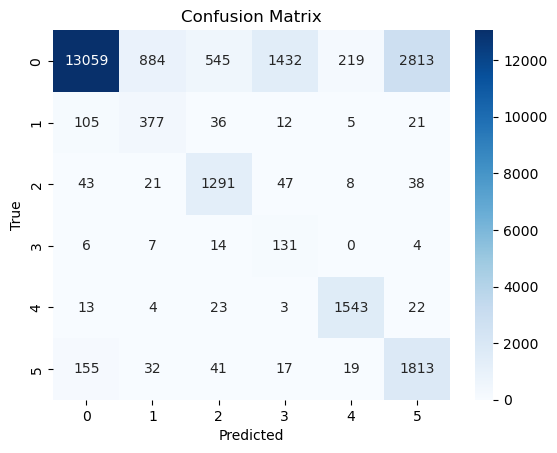

              precision    recall  f1-score   support

           0       0.98      0.69      0.81     18952
           1       0.28      0.68      0.40       556
           2       0.66      0.89      0.76      1448
           3       0.08      0.81      0.15       162
           4       0.86      0.96      0.91      1608
           5       0.38      0.87      0.53      2077

    accuracy                           0.73     24803
   macro avg       0.54      0.82      0.59     24803
weighted avg       0.88      0.73      0.78     24803



In [ ]:
# Predict classes
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Classification report
print(classification_report(y_true_classes, y_pred_classes))

C:\Users\plui0\AppData\Local\Temp\ipykernel_27764\4199253349.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', num_classes)


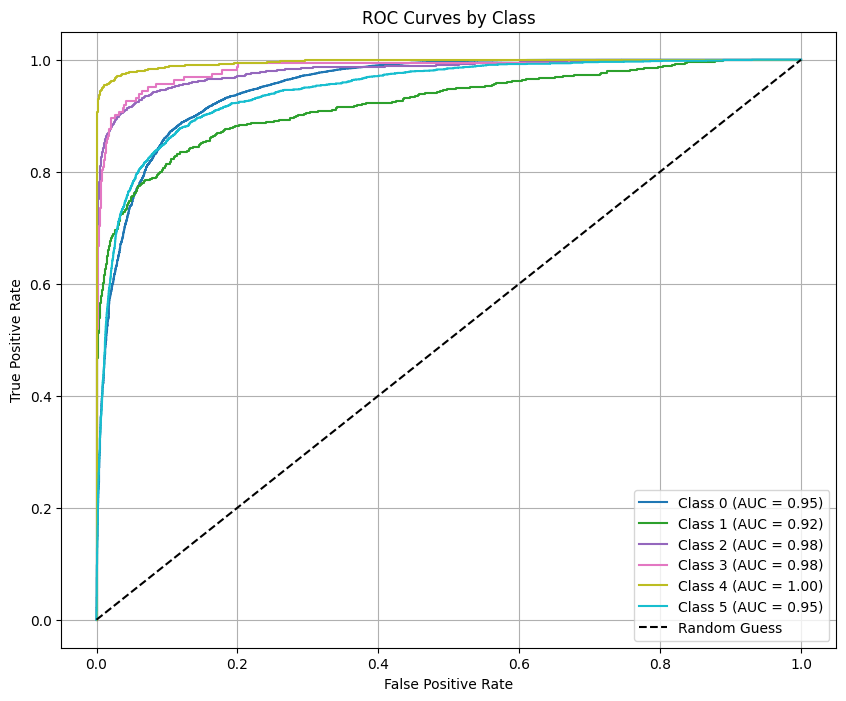

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Number of classes
num_classes = y_test.shape[1]

# Compute ROC curve and AUC for each class
fpr = {}
tpr = {}
roc_auc = {}

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 8))
colors = plt.cm.get_cmap('tab10', num_classes)

for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})", color=colors(i))

plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves by Class")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
